### Transformer Model Fine Tuning

Fine tune transformer model for follow-through prediction using labeled VWAP Reclaim entries. 
- P(follow_through) - whether trade will move >= 3.0 ATR in 24 bars.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import math
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import precision_score, recall_score

For fine tuning, smaller batch sizes will be utilized. Two-phase fine tuning approach will be used.
- Phase 1: freeze encoder, train only the classification head
- Phase 2: unfreeze encoder, fine-tune everything with lower learning rate

Due to class imbalance, weights will be calculated and assigned.

In [2]:
# config
SEQ_LEN = 48
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
D_FF = 256
DROPOUT = 0.1
SYMBOL_EMB = 8
SYMBOLS = ['COIN', 'NVDA', 'OKLO', 'PLTR', 'TSLA']

# fine tuning specs
BATCH_SIZE = 32
PHASE1_EPOCHS = 20
PHASE2_EPOCHS = 30
PHASE1_LR = 1e-3
PHASE2_LR = 1e-4
PATIENCE = 7
# label distribution used for weight
POS_WEIGHT = 1074 / 782
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# trade entry features
ENTRY_FEAT_COLS = [
    'tod_sin',
    'tod_cos',
    'vwap_dist_atr',
    'vol_ratio_24',
    'atr_pct_12',
    'ret_1',
]
N_ENTRY_FEATURES = len(ENTRY_FEAT_COLS)

In [3]:
# load scaler stats
with open('feature_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

FEATURE_COLS = scaler['feature_cols']
feat_mean = scaler['mean']
feat_std = scaler['std']
N_FEATURES = len(FEATURE_COLS)
INPUT_DIM = N_FEATURES + SYMBOL_EMB

print(f"POS_WEIGHT: {POS_WEIGHT:.3f}")

POS_WEIGHT: 1.373


In [4]:
# load 5M data and entries

# raw 5M price data
df = pd.read_csv('multiasset_5m_rth_features.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['ts_ny'] = df['timestamp'].dt.tz_convert('America/New_York')
df['session_date'] = df['ts_ny'].dt.date
df['date_ny'] = pd.to_datetime(df['session_date'])
df['symbol_id'] = df['symbol'].map({s: i for i, s in enumerate(SYMBOLS)})

# vwap reclaim entries
entries = pd.read_csv('multiasset_labeled_entries.csv')
entries['date_ny'] = pd.to_datetime(entries['date_ny'])

# validate splits
print("Entry split distribution:")
print(entries['split'].value_counts().sort_index())

print(f"\n5M data shape: {df.shape}")
print(f"Entries shape: {entries.shape}")

Entry split distribution:
split
test      295
train    1272
val       289
Name: count, dtype: int64

5M data shape: (171692, 31)
Entries shape: (1856, 40)


In [5]:
entries.columns.tolist()

['symbol',
 'timestamp',
 'date_ny',
 'i_signal',
 'i_entry',
 'ts_signal',
 'ts_entry',
 'entry_price',
 'entry_atr',
 'side',
 'split',
 'ret_1',
 'ret_3',
 'ret_6',
 'ret_12',
 'ret_18',
 'ret_24',
 'atr_12',
 'atr_pct_12',
 'vwap_dist',
 'vwap_dist_atr',
 'vol_ratio_24',
 'rv_12',
 'range_pct',
 'body_pct',
 'upper_wick_pct',
 'lower_wick_pct',
 'tod_sin',
 'tod_cos',
 'mfe_atr',
 'mae_atr',
 'time_to_peak_bars',
 'follow_through',
 'R_scalp',
 'exit_reason_scalp',
 'R_hold',
 'exit_reason_hold',
 'R_oracle',
 'risk_oracle',
 'exit_reason_oracle']

Extract entry sequence from 5M data. For each vwap reclaim entry, extract 48 bars immediately before entry from the same stock and session. If sequence is too short, left padd with zeros. loaded scaler normalization will be applied.

In [6]:
# extract entry sequence
def extract_entry_sequence(df, i_entry, symbol, date_ny, seq_len=SEQ_LEN):
    start_idx = max(0, i_entry - seq_len - 10)
    window = df.iloc[start_idx : i_entry]
    window = window[
        (window['symbol'] == symbol) &
        (window['date_ny'] == date_ny)
    ]
    window = window.tail(seq_len)
    # extract and normalize features
    feats = window[FEATURE_COLS].values.astype(np.float32)
    feats = (feats - feat_mean.values) / feat_std.values
    feats = np.nan_to_num(feats, nan=0.0)
    feats = np.clip(feats, -5.0, 5.0)
    # left pad with zeros if sequence is too short
    if len(feats) < seq_len:
        pad = np.zeros((seq_len - len(feats), N_FEATURES), dtype=np.float32)
        feats = np.vstack([pad, feats])

    return feats

In [7]:
# extract sequence for all vwap reclaim entries
sequences = []
symbol_ids = []
skipped = 0

for _, row in entries.iterrows():
    i_entry = int(row['i_entry'])
    symbol = row['symbol']
    date_ny = row['date_ny']
    sym_id = SYMBOLS.index(symbol)

    seq = extract_entry_sequence(df, i_entry, symbol, date_ny)

    if seq.shape != (SEQ_LEN, N_FEATURES):
        skipped += 1
        continue

    sequences.append(seq)
    symbol_ids.append(sym_id)

sequences = np.array(sequences, dtype=np.float32)
symbol_ids = np.array(symbol_ids, dtype=np.int64)

print(f"Sequences extracted: {len(sequences):,}")
print(f"Skipped: {skipped}")
print(f"Sequences shape: {sequences.shape}")
pad_count = sum(
    1 for seq in sequences if (seq[:SEQ_LEN//4] == 0).all()
)
print(f"~{pad_count} sequences with leading zeros")

Sequences extracted: 1,856
Skipped: 0
Sequences shape: (1856, 48, 16)
~1069 sequences with leading zeros


Create fine tuning dataset with 48 bars, stock id, and follow through label. 

In [8]:
# create entry sequence data
class EntrySequenceDataset(Dataset):
    def __init__(self, entries_df, sequences, symbol_ids):
        self.sequences = sequences
        self.symbol_ids = symbol_ids
        self.labels = entries_df['follow_through'].values.astype(np.float32)

        # extract and normalize entry-level features using saved scaler
        entry_feats = entries_df[ENTRY_FEAT_COLS].copy()
        for col in ENTRY_FEAT_COLS:
            if col in feat_mean.index:
                entry_feats[col] = (entry_feats[col] - feat_mean[col]) / feat_std[col]
        entry_feats = entry_feats.fillna(0.0).clip(-5.0, 5.0)
        self.entry_feats = entry_feats.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx]),
            torch.tensor(self.symbol_ids[idx]),
            torch.tensor(self.entry_feats[idx]),
            torch.tensor(self.labels[idx])
        )

# split data
train_mask = entries['split'] == 'train'
val_mask = entries['split'] == 'val'
test_mask = entries['split'] == 'test'

# create datasets
train_dataset = EntrySequenceDataset(
    entries[train_mask].reset_index(drop=True),
    sequences[train_mask.values],
    symbol_ids[train_mask.values]
)
val_dataset = EntrySequenceDataset(
    entries[val_mask].reset_index(drop=True),
    sequences[val_mask.values],
    symbol_ids[val_mask.values]
)
test_dataset = EntrySequenceDataset(
    entries[test_mask].reset_index(drop=True),
    sequences[test_mask.values],
    symbol_ids[test_mask.values]
)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset):,} entries FT rate: {train_dataset.labels.mean():.1%}")
print(f"Val: {len(val_dataset):,} entries FT rate: {val_dataset.labels.mean():.1%}")
print(f"Test: {len(test_dataset):,} entries FT rate: {test_dataset.labels.mean():.1%}")
print(f"\nTrain batches: {len(train_loader)}")

Train: 1,272 entries FT rate: 41.7%
Val: 289 entries FT rate: 45.7%
Test: 295 entries FT rate: 40.7%

Train batches: 40


Create fine tuning model. Model architecture will be identical to pre-train model architecture. Classification head will be attached for follow-through-prediction.

In [9]:
# sinusoida encoding
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=DROPOUT):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# core encoder
class BarTransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.symbol_embedding = nn.Embedding(len(SYMBOLS), SYMBOL_EMB)
        self.input_proj = nn.Linear(INPUT_DIM, D_MODEL)
        self.pos_encoding = SinusoidalPositionalEncoding(D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=N_HEADS, dim_feedforward=D_FF,
            dropout=DROPOUT, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=N_LAYERS, enable_nested_tensor=False
        )
        self.norm = nn.LayerNorm(D_MODEL)

    def forward(self, x, symbol_id):
        sym_emb = self.symbol_embedding(symbol_id)
        sym_emb = sym_emb.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, sym_emb], dim=-1)
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        return self.norm(x)

# follow through classifier
class FollowThroughClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = BarTransformerEncoder()
        self.classifier = nn.Sequential(
            nn.Linear(D_MODEL + N_ENTRY_FEATURES, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x, symbol_id, entry_feats):
        enc_out = self.encoder(x, symbol_id)
        pooled = enc_out.mean(dim=1)
        combined = torch.cat([pooled, entry_feats], dim=-1)
        logit = self.classifier(combined)
        return logit.squeeze(-1) 

In [10]:
# load pre-trained encoder weights
model = FollowThroughClassifier().to(DEVICE)
model.encoder.load_state_dict(
    torch.load('transformer_encoder_pretrained.pt', map_location=DEVICE)
)

total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
head_params = sum(p.numel() for p in model.classifier.parameters())

print(f"\nTotal params: {total_params:,}")
print(f"Encoder params: {encoder_params:,}")
print(f"Classifier head: {head_params:,} (input: {D_MODEL} + {N_ENTRY_FEATURES} = {D_MODEL + N_ENTRY_FEATURES})")

# loss function with class weights
pos_weight = torch.tensor([POS_WEIGHT]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"\npos_weight={POS_WEIGHT:.3f}")


Total params: 104,041
Encoder params: 101,736
Classifier head: 2,305 (input: 64 + 6 = 70)

pos_weight=1.373


Two phase fine tuning starting with phase 1 by freezing encoder to train classifier head and phase 2 unfreezing encoder to fine tune everything at lower learning rate.

In [11]:
# epoch runner
def run_epoch(loader, model, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    # track gradients during training
    with torch.set_grad_enabled(train):
        for x_batch, sid_batch, ef_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            sid_batch = sid_batch.to(DEVICE)
            ef_batch = ef_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            # forward pass
            logits = model(x_batch, sid_batch, ef_batch)
            loss = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            # convert logits to binary preds
            total_loss += loss.item()
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.extend((probs > 0.5).astype(int))
            all_labels.extend(y_batch.cpu().numpy().astype(int))

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, f1

# train
def train_phase(phase, epochs, lr, freeze_encoder):
    print(f"Phase {phase} - encoder {'FROZEN' if freeze_encoder else 'UNFROZEN'} LR={lr}")
    print(f"{'Epoch':>6} {'Train Loss':>11} {'Train F1':>10} {'Val Loss':>10} {'Val F1':>8}")
    # freeze or unfreeze encoder
    for param in model.encoder.parameters():
        param.requires_grad = not freeze_encoder

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/10)

    best_val_loss = float('inf')
    patience_counter = 0
    # run training epoch and val epoch
    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = run_epoch(train_loader, model, criterion, optimizer, train=True)
        val_loss, val_f1 = run_epoch(val_loader, model, criterion, train=False)
        scheduler.step()

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'follow_through_classifier.pt')
        else:
            patience_counter += 1

        print(f"{epoch:>6} {train_loss:>11.4f} {train_f1:>10.4f} {val_loss:>10.4f} {val_f1:>8.4f}")
        # early stopping
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    print(f"Best val loss: {best_val_loss:.4f}")

# run phase 1 and phase 2
train_losses_p1, val_losses_p1 = [], []
train_losses_p2, val_losses_p2 = [], []

train_phase(phase=1, epochs=PHASE1_EPOCHS, lr=PHASE1_LR, freeze_encoder=True)
train_phase(phase=2, epochs=PHASE2_EPOCHS, lr=PHASE2_LR, freeze_encoder=False)

print("\nmodel saved to follow_through_classifier.pt")

Phase 1 - encoder FROZEN LR=0.001
 Epoch  Train Loss   Train F1   Val Loss   Val F1
     1      0.8039     0.4335     0.7930   0.6263
     2      0.7737     0.5786     0.7939   0.4301
     3      0.7475     0.5750     0.7623   0.5571
     4      0.7317     0.6008     0.7326   0.6304
     5      0.7174     0.6041     0.7270   0.6204
     6      0.7115     0.6211     0.7275   0.5897
     7      0.7123     0.6125     0.7080   0.6415
     8      0.7047     0.6151     0.7295   0.5766
     9      0.7002     0.6229     0.7251   0.5804
    10      0.7030     0.6179     0.6992   0.6312
    11      0.6927     0.6431     0.7050   0.6033
    12      0.6932     0.6208     0.7056   0.6109
    13      0.6907     0.6328     0.7011   0.6041
    14      0.6937     0.6230     0.6994   0.6129
    15      0.6966     0.6363     0.6981   0.6129
    16      0.6908     0.6248     0.6984   0.6204
    17      0.6887     0.6326     0.6966   0.6080
    18      0.6821     0.6420     0.6985   0.6148
    19      0.69

In [27]:
# load best model
model.load_state_dict(torch.load('follow_through_classifier.pt', map_location=DEVICE))
model.eval()

FollowThroughClassifier(
  (encoder): BarTransformerEncoder(
    (symbol_embedding): Embedding(5, 8)
    (input_proj): Linear(in_features=24, out_features=64, bias=True)
    (pos_encoding): SinusoidalPositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      

In [28]:
# score validation set
val_probs, val_labels = [], []

with torch.no_grad():
    for x_batch, sid_batch, ef_batch, y_batch in val_loader:
        x_batch = x_batch.to(DEVICE)
        sid_batch = sid_batch.to(DEVICE)
        ef_batch = ef_batch.to(DEVICE)

        logits = model(x_batch, sid_batch, ef_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        val_probs.extend(probs)
        val_labels.extend(y_batch.numpy().astype(int))

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

# validation trade outcomes for P&L threshold review
val_returns = (
    entries.loc[entries["split"] == "val", ["R_scalp", "R_hold"]]
    .reset_index(drop=True)
)
assert len(val_returns) == len(val_probs)

thresholds = np.arange(0.30, 0.80, 0.05)

# ml thresholds
ml_results = []

print(f"\n{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Hold Calls':>12}")
for t in thresholds:
    preds = (val_probs >= t).astype(int)

    precision = precision_score(val_labels, preds, pos_label=1, zero_division=0)
    recall = recall_score(val_labels, preds, pos_label=1, zero_division=0)
    f1 = f1_score(val_labels, preds, zero_division=0)
    hold_calls = int(preds.sum())

    ml_results.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "hold_calls": hold_calls
    })

    print(f"{t:>10.2f} {precision:>10.3f} {recall:>8.3f} {f1:>8.3f} {hold_calls:>12}")

ml_results_df = pd.DataFrame(ml_results)
print(f"\nValidation ROC-AUC: {roc_auc_score(val_labels, val_probs):.4f}")

# P&L thresholds
pnl_results = []

print(f"\n{'Threshold':>10} {'Total R':>10} {'Avg R':>8} {'Precision':>10} {'Hold Calls':>12}")
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    chosen_R = np.where(preds == 1, val_returns["R_hold"], val_returns["R_scalp"])

    total_R = chosen_R.sum()
    avg_R = chosen_R.mean()
    precision = precision_score(val_labels, preds, pos_label=1, zero_division=0)
    hold_calls = int(preds.sum())

    pnl_results.append({
        "threshold": t,
        "total_R": total_R,
        "avg_R": avg_R,
        "precision": precision,
        "hold_calls": hold_calls
    })

    print(f"{t:>10.2f} {total_R:>10.3f} {avg_R:>8.3f} {precision:>10.3f} {hold_calls:>12}")

pnl_results_df = pd.DataFrame(pnl_results).sort_values(
    ["total_R", "precision"], ascending=[False, False]
).reset_index(drop=True)


 Threshold  Precision   Recall       F1   Hold Calls
      0.30      0.549    0.886    0.678          213
      0.35      0.589    0.826    0.688          185
      0.40      0.623    0.788    0.696          167
      0.45      0.657    0.712    0.684          143
      0.50      0.672    0.636    0.654          125
      0.55      0.738    0.576    0.647          103
      0.60      0.791    0.545    0.646           91
      0.65      0.795    0.470    0.590           78
      0.70      0.824    0.424    0.560           68
      0.75      0.845    0.371    0.516           58

Validation ROC-AUC: 0.7794

 Threshold    Total R    Avg R  Precision   Hold Calls
      0.30      8.714    0.030      0.549          213
      0.35      9.198    0.032      0.589          185
      0.40     11.393    0.039      0.623          167
      0.45     10.350    0.036      0.657          143
      0.50     13.350    0.046      0.672          125
      0.55     24.438    0.085      0.738          103
  

Based on the validation thresholds, we'll proceed with operating threshold of 0.55 to be more selective on follow through predictions but still have a meaning number of predictions in addition to yielding the higher return.

In [30]:
OPERATING_THRESHOLD = 0.55

# score test set
test_probs, test_labels = [], []

with torch.no_grad():
    for x_batch, sid_batch, ef_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        sid_batch = sid_batch.to(DEVICE)
        ef_batch = ef_batch.to(DEVICE)

        logits = model(x_batch, sid_batch, ef_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        test_probs.extend(probs)
        test_labels.extend(y_batch.numpy().astype(int))

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds = (test_probs >= OPERATING_THRESHOLD).astype(int)

print(classification_report(test_labels, test_preds, target_names=["Scalp", "Hold"], digits=3))
print(f"Test ROC-AUC: {roc_auc_score(test_labels, test_probs):.4f}")

              precision    recall  f1-score   support

       Scalp      0.709     0.903     0.794       175
        Hold      0.764     0.458     0.573       120

    accuracy                          0.722       295
   macro avg      0.736     0.681     0.683       295
weighted avg      0.731     0.722     0.704       295

Test ROC-AUC: 0.7874


Due to class imbalance between scalp vs hold, accuracy is not a good metric to follow and precision on hold class should be prioritized for real trading systems. An ROC-AUC of 0.7874 means the model has an ability to separate classes.

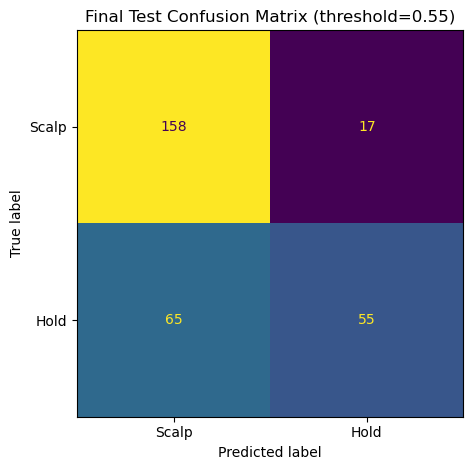

In [32]:
# confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Scalp", "Hold"])
disp.plot(colorbar=False)
plt.title(f"Final Test Confusion Matrix (threshold={OPERATING_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

In [33]:
# generate predictions
full_dataset = EntrySequenceDataset(
    entries.reset_index(drop=True),
    sequences,
    symbol_ids
)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_probs_full = []

with torch.no_grad():
    for x_batch, sid_batch, ef_batch, _ in full_loader:
        x_batch = x_batch.to(DEVICE)
        sid_batch = sid_batch.to(DEVICE)
        ef_batch = ef_batch.to(DEVICE)

        logits = model(x_batch, sid_batch, ef_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs_full.extend(probs)

all_probs_full = np.array(all_probs_full)

entries['p_follow_through'] = all_probs_full
entries['pred_follow_through'] = (all_probs_full >= OPERATING_THRESHOLD).astype(int)

output_cols = [
    'symbol', 'timestamp', 'date_ny', 'ts_entry',
    'entry_price', 'entry_atr', 'split',
    'follow_through',
    'p_follow_through', 'pred_follow_through',
    'mfe_atr', 'mae_atr',
    'R_scalp', 'exit_reason_scalp',
    'R_hold', 'exit_reason_hold',
    'R_oracle', 'risk_oracle', 'exit_reason_oracle'
]

entries[output_cols].to_csv('entry_predictions.csv', index=False)

print(f"\nPrediction distribution by split:")
print(entries.groupby('split')['pred_follow_through'].agg(['sum', 'count', 'mean']).round(3))


Prediction distribution by split:
       sum  count   mean
split                   
test    72    295  0.244
train  410   1272  0.322
val    103    289  0.356
